In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.interpolate import interp1d
import corner
from radmc3dPy import image
# from CB68.data_dict import data_dict
from make_conti import generate_model

In [87]:
def rotate_image(image, posang):
  if isinstance(image, np.ndarray)!=True:
    image.imageJyppix= ndimage.rotate(image.imageJyppix, posang, reshape=False, axes=(1, 0))
    image.imageJyppix = np.nan_to_num(image.imageJyppix, nan=0)
    return image.imageJyppix
  else:
    image = ndimage.rotate(image, posang, reshape=False, axes=(1, 0))
    image = np.nan_to_num(image, nan=0)
    return image
  
def radial_intensity(image_array, center, width):
  radial_profile = np.mean(image_array[:, center-width//2:center+width//2], axis=1)
  return radial_profile

In [88]:
edisk_radial = np.load("edisk_radial.npz")

In [89]:
interp_func = interp1d(np.linspace(0, 1, 190), edisk_radial["i_r"], kind='cubic')
i_r_obs = interp_func(np.linspace(0, 1, 500))

In [90]:
sizeau = 80
npix = 500
pixel_area = (sizeau/npix/140)**2
beam_axis = [0.0363, 0.0274]
beam_area = beam_axis[0]*beam_axis[1]*np.pi/(4*np.log(2))
r_axis = np.linspace(-(sizeau//2), sizeau//2, npix, endpoint=True)

In [91]:
# a_list = [1e-2, 1e-1, 1e0, 1e1, 1e2]
# L_star_list = [1e-1, 5e-1, 1e0, 5e0, 1e1, 5e1]
# Q_list = [0.5, 1, 1.5]
# mdot_list = [1e-8, 1e-7, 1e-6]


# chi_list = []
# idx_list = []
# def chi(i_r_model, i_r_obs):
#     return np.sum(((i_r_model - i_r_obs)**2)/(21e-6**2))

# for idx_a, a in enumerate(a_list):
#     for idx_l, L_star in enumerate(L_star_list):
#         for idx_q, Q in enumerate(Q_list):
#             for idx_mdot, mdot in enumerate(mdot_list):
#                 # model = generate_model(a, L_star, Q, mdot, heat = "radiation")
#                 im = image.readImage(fname=f'./test/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_radiation_scat.out')
#                 im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)


#                 im_conv = rotate_image(im_conv, 45)

#                 im_conv *= beam_area/pixel_area/(140**2)
                

#                 i_r = radial_intensity(im_conv, npix//2, 10)
#                 interp_func = interp1d(np.linspace(0, 1, 500), i_r[:, 0], kind='cubic')
#                 i_r_model = interp_func(np.linspace(0, 1, 190))
#                 chi_list.append(chi(i_r_model, edisk_radial["i_r"])*pixel_area/beam_area)
#                 idx_list.append((idx_a, idx_l, idx_q, idx_mdot))
                # plt.plot(r_axis, i_r*1e3, label=" radiation model")
                # plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="eDisk", linestyle="--")
                # plt.xlim((-(sizeau//2), sizeau//2))
                # plt.ylim(bottom=0)
                # plt.xlabel("Offset (AU)")
                # plt.ylabel("Intensity (mJy/beam)")
                # plt.title(f"Continuum radial profile along the major axis")
                # plt.legend()
                # plt.savefig(f"./figures/a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}.pdf", transparent=True)
                # plt.close("all")



In [92]:
# print(chi_list.index(min(chi_list)))
# print(idx_list[chi_list.index(min(chi_list))])
# print(max(chi_list))

In [93]:
# color_val = np.log(chi_list)


In [94]:
# fig, ax = plt.subplots(1, 6, figsize=(20, 4))
# for idx_a, a in enumerate(a_list):
#     for idx_l, L_star in enumerate(L_star_list):
#         for idx_q, Q in enumerate(Q_list):
#             for idx_mdot, mdot in enumerate(mdot_list):
#                 chi = np.log(chi_list[idx_list.index((idx_a, idx_l, idx_q, idx_mdot))])
#                 ax[0].scatter(a, L_star, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[1].scatter(a, Q, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[2].scatter(a, mdot, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[3].scatter(L_star, Q, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[4].scatter(L_star, mdot, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[5].scatter(Q, mdot, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[0].set_yscale("log");ax[0].set_xscale("log")
#                 ax[1].set_yscale("log");ax[1].set_xscale("log")
#                 ax[2].set_yscale("log");ax[2].set_xscale("log")
#                 ax[3].set_yscale("log");ax[3].set_xscale("log")
#                 ax[4].set_yscale("log");ax[4].set_xscale("log")
#                 ax[5].set_yscale("log");ax[5].set_xscale("log")
                

In [95]:
a = 1e-2
L_star = 3e0
Q = 1
mdot = 1e-6
heat = "irradiation"
generate_model(a, L_star, Q, mdot, heat)


You have 24 Processors
get_continuumlambda: No input wavelength.
get_continuumlambda: Re-creating wavelength_micron.inp using default wavelengths.
  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github              

Reading ./test/outfile/conti_a_0.01_Lstar_3.0_Q_1_mdot_1e-06_irradiation_scat.out


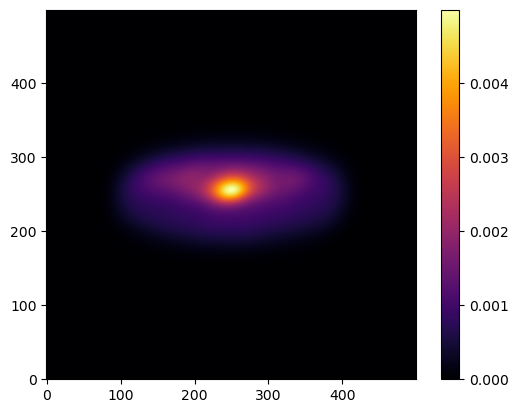

In [96]:
im = image.readImage(fname=f'./test/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)


im_conv = rotate_image(im_conv, 45)

im_conv *= beam_area/pixel_area/(140**2)
# T_b = 1.36*(1.3e-1)**2/(beam_axis[0]*beam_axis[1])*im_conv*1e3
# # print(1.36*(1.3e-1)**2/(beam_axis[0]*beam_axis[1])*3)
plt.imshow(im_conv[:,:,0].T, origin="lower", cmap="inferno")
plt.colorbar()
plt.show()

In [97]:
# edisk_radial = np.load("edisk_radial.npz")


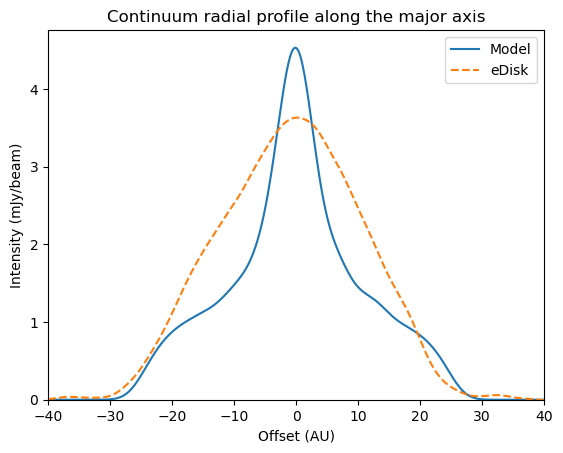

In [98]:
i_r = radial_intensity(im_conv, npix//2, 10)
plt.plot(r_axis, i_r*1e3, label="Model")
plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="eDisk", linestyle="--")
plt.xlim((-(sizeau//2), sizeau//2))
plt.ylim(bottom=0)
plt.xlabel("Offset (AU)")
plt.ylabel("Intensity (mJy/beam)")
plt.title(f"Continuum radial profile along the major axis")
plt.legend()